In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\user\my_snippet\DataSets\coffee_shop.csv',encoding='UTF-8')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [2]:
#data clean
len(df['transaction_id']),df['transaction_id'].nunique()
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [3]:
#essential measure
df['datetime'] = pd.to_datetime(df['transaction_date']+' ' +df['transaction_time'],format='%d-%m-%Y %H:%M:%S')
df['revenue'] = df['unit_price']*df['transaction_qty']

In [4]:
#monthly revenue
df.resample('ME',on='datetime')['revenue'].sum()#.plot(kind= 'bar')

datetime
2023-01-31     81677.74
2023-02-28     76145.19
2023-03-31     98834.68
2023-04-30    118941.08
2023-05-31    156727.76
2023-06-30    166485.88
Freq: ME, Name: revenue, dtype: float64

In [5]:
#most revenue generator store
df.groupby('store_location')['revenue'].sum().idxmax()

"Hell's Kitchen"

In [6]:
df['hour'] = df['datetime'].dt.hour
#hourwise revenue
#df.groupby('hour')['revenue'].sum().plot(color='red',marker='o')
#top-hour
df.groupby('store_location')['hour'].value_counts().groupby(level=0).head(3)

store_location   hour
Astoria          10      5291
                 9       5083
                 8       4966
Hell's Kitchen   10      6957
                 8       6909
                 9       6767
Lower Manhattan  10      6297
                 9       5914
                 7       5792
Name: count, dtype: int64

In [7]:
#most revenuer prod
g = df.groupby('product_category')
#g['revenue'].sum().plot(kind='bar')

#byquantity
g['transaction_qty'].sum().sort_values()

#less sales more revenue
g = df[df['transaction_qty']<df['transaction_qty'].mean()]


<Axes: title={'center': 'Revenu and Quantity Sold'}, xlabel='transaction_qty', ylabel='revenue'>

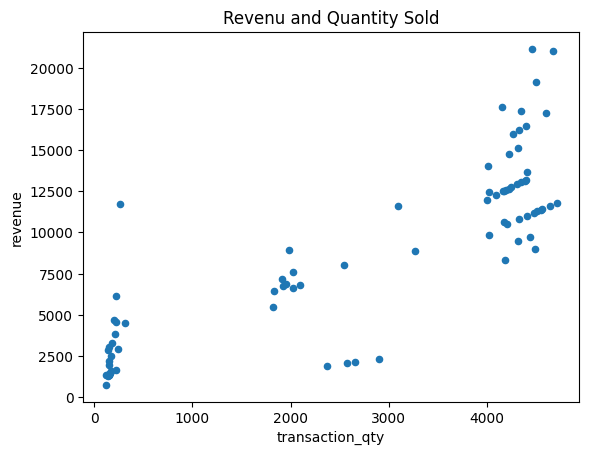

In [8]:
g = df.groupby('product_detail').agg({
    'transaction_qty':'sum',
    'revenue':'sum'
})
g.sort_values(['transaction_qty']).plot(kind='scatter',x='transaction_qty',
                                        y='revenue',title='Revenu and Quantity Sold',
                                        xlabel='transaction_qty',ylabel='revenue',marker='o')


<Axes: title={'center': 'Revenue vs Quantity Sold'}, xlabel='Quantity Sold', ylabel='Revenue'>

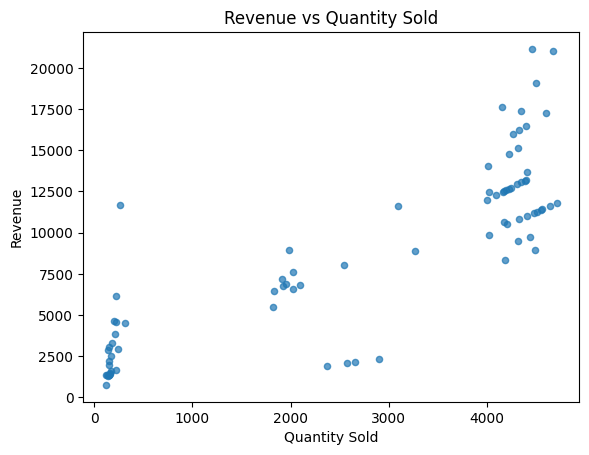

In [9]:
g = df.groupby('product_detail').agg({
    'transaction_qty':'sum',
    'revenue':'sum'
})

g.plot(
    kind='scatter',
    x='transaction_qty',
    y='revenue',
    title='Revenue vs Quantity Sold',
    xlabel='Quantity Sold',
    ylabel='Revenue',
    alpha=0.7
)

In [10]:
low_qt= g['transaction_qty'].quantile(0.25)
high_qt= g['transaction_qty'].quantile(0.75)
premium = g[(g['transaction_qty']<100) &
            (g['revenue']>5000)
]
low_qt,high_qt,premium

(np.float64(221.0),
 np.float64(4326.0),
 Empty DataFrame
 Columns: [transaction_qty, revenue]
 Index: [])

In [11]:
g['revenue_per_unit'] = g['revenue']/g['transaction_qty']
g.sort_values('revenue_per_unit',ascending=False)

,transaction_qty,revenue,revenue_per_unit
product_detail,,,
Civet Cat,260,11700.0,45.000000
I Need My Bean! T-shirt,221,6163.0,27.886878
Organic Decaf Blend,206,4657.5,22.609223
Ethiopia,218,4578.0,21.000000
Primo Espresso Roast,150,3067.5,20.450000
...,...,...,...
Columbian Medium Roast Sm,4178,8356.0,2.000000
Chocolate syrup,2658,2126.4,0.800000
Carmel syrup,2576,2060.8,0.800000


<Axes: xlabel='hour'>

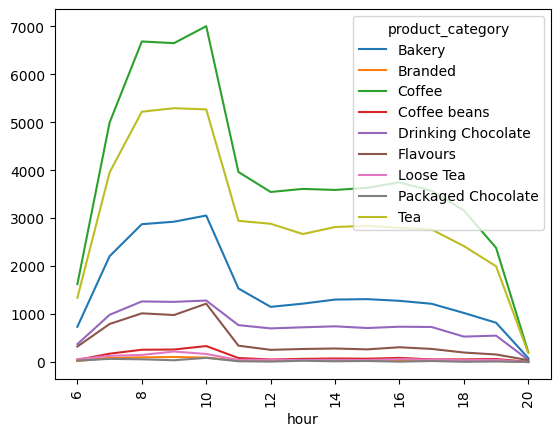

In [32]:
#morning hour analysis
g = df.groupby('hour')['product_category'].value_counts().unstack()
g.plot(rot=90)

<Axes: xlabel='product_category', ylabel='hour'>

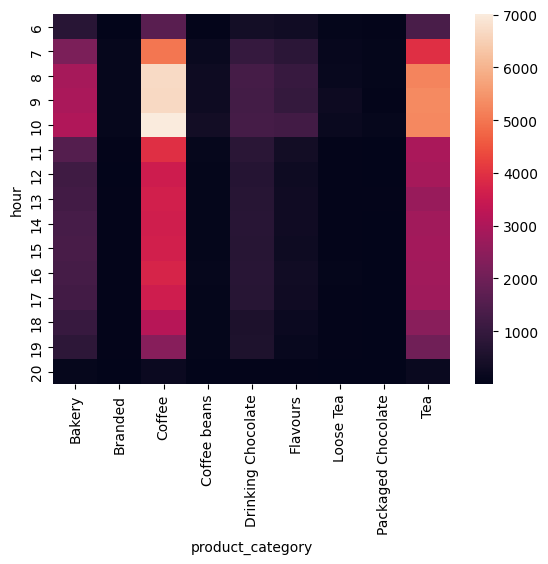

In [34]:
import seaborn as sns

g = df.groupby('hour')['product_category'].value_counts().unstack(fill_value=0)

sns.heatmap(g)

<Axes: xlabel='hour'>

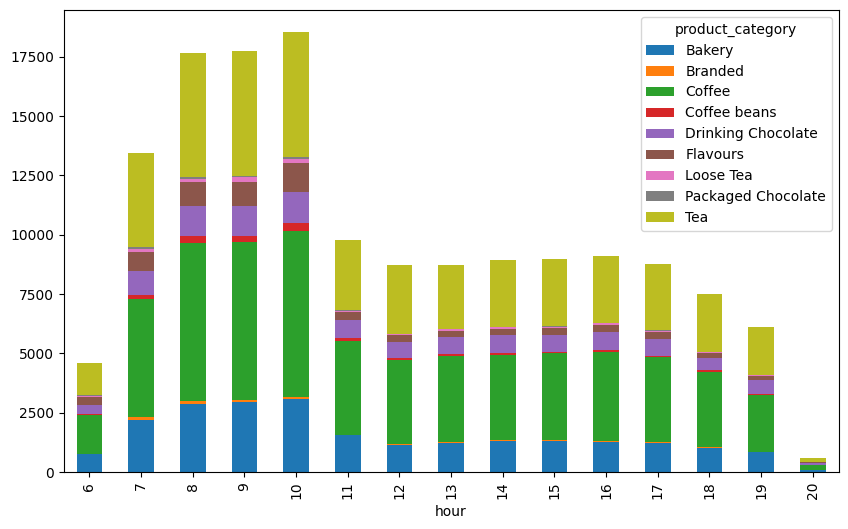

In [35]:
g = df.groupby('hour')['product_category'].value_counts().unstack()

g.plot(kind='bar', stacked=True, figsize=(10,6))